## Embryo vs gastruloids marker lineplots

In [315]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load data

In [316]:
# embryo
embryo_pseudo = pd.read_excel('../data/pseudobulk/mouse_embryonic_pseudobulk_by_stage.xlsx', sheet_name='Sheet 1')
embryo_pseudo['gene_symbol'].replace('T','Tbxt', inplace=True)
embryo_pseudo = embryo_pseudo.set_index("gene_symbol")
embryo_pseudo.drop(columns='gene_ID', inplace=True)
embryo_pseudo.head()

/tmp/ipykernel_10358/889049287.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  embryo_pseudo['gene_symbol'].replace('T','Tbxt', inplace=True)


,E6.5,E6.75,E7.0,E7.25,E7.5,E7.75,E8.0,E8.25,E8.5
gene_symbol,,,,,,,,,
Xkr4,2,0,7,6,9,17,7,10,5
Gm1992,0,0,0,0,0,0,0,0,0
Gm37381,0,0,0,0,0,0,0,1,0
Rp1,0,0,2,2,2,25,13,7,7
Sox17,19,88,5670,5585,4497,2914,3630,3218,2980


## embryo timecourse lineplot

In [ ]:
genes = ['Eomes', 'Nodal', 'Wnt3', 'Fgf5', 'Utf1','Tbxt', 'Cdx2', 'Wnt3a', 'Hoxa1', 'Hoxb1']
genes_black = ['Gsc', 'Lhx1', 'Nanog', 'Cer1', 'Foxa2', 'Chrd'] + genes

In [365]:
palette_v1 = {
    "Fgf5": "#1f77b4",   # deep blue
    "Utf1": "#63a0cf",   # sky blue
    "Nodal": "#2ca02c",  # forest green
    "Eomes": "#66c266",  # lime green
    "Wnt3": "#98d698",   # light green
    "Tbxt": "#d62728",   # dark red
    "Wnt3a": "#ff6b6b",  # coral red
    "Cdx2": "#ff8c6d",   # salmon
    "Hoxa1": "#ffb399",  # peach
    "Hoxb1": "#ffd1cc"   # very light red/pink
}


palette_v2 = {
    "Eomes": "#2ca02c",   # forest green
    "Utf1": "#66c266",   # lime green
    "Nodal": "#98d698",  # light green
    "Fgf5": "#b2e2b2",  # pale green
    "Wnt3": "#cce5cc",   # very light green
    "Tbxt": "#d62728",   # dark red
    "Wnt3a": "#ff6b6b",  # coral red
    "Cdx2": "#ff8c6d",   # salmon
    "Hoxa1": "#ffb399",  # peach
    "Hoxb1": "#ffd1cc"   # very light red/pink
}

palette_v3 = {
    "Eomes": "#2ca02c",   # forest green
    "Utf1": "#66c266",   # lime green
    "Nodal": "#98d698",  # light green
    "Fgf5": "#b2e2b2",  # pale green
    "Wnt3": "#cce5cc",   # very light green
    "Tbxt": "#d62728",   # dark red
    "Wnt3a": "#ff6b6b",  # coral red
    "Cdx2": "#ff8c6d",   # salmon
    "Hoxa1": "#ffb399",  # peach
    "Hoxb1": "#ffd1cc",   # very light red/pink
    'Gsc':   '#888888',
    'Lhx1':  '#888888',
    'Nanog': '#888888',
    'Cer1':  '#888888',
    'Foxa2': '#888888',
    'Chrd':  '#888888'
}


In [366]:
df = embryo_pseudo.loc[genes,:]

# lognormalize
logdf = np.log1p(df)

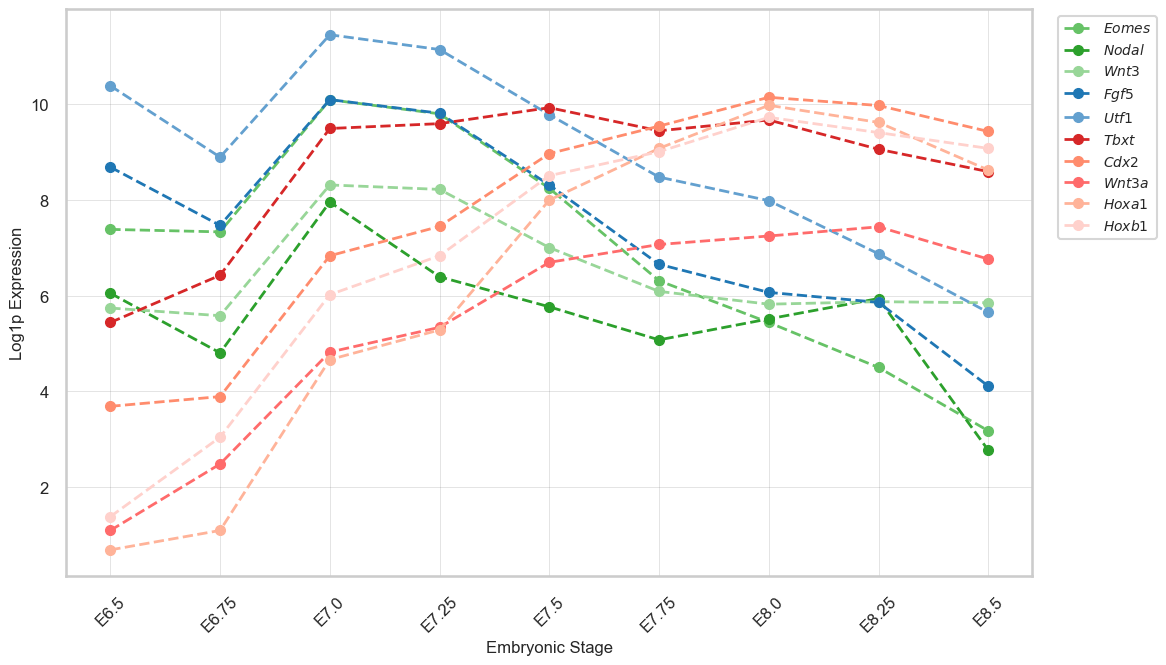

In [367]:
# contruct lineplot
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

palette = palette_v1
for i, gene in enumerate(genes):
    plt.plot(
        logdf.columns,
        logdf.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )

plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.xlabel('Embryonic Stage', fontsize=12)
plt.ylabel('Log1p Expression', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('../results/lineplot_embryo_pseudobulk_v1.svg', format='svg')
plt.show()

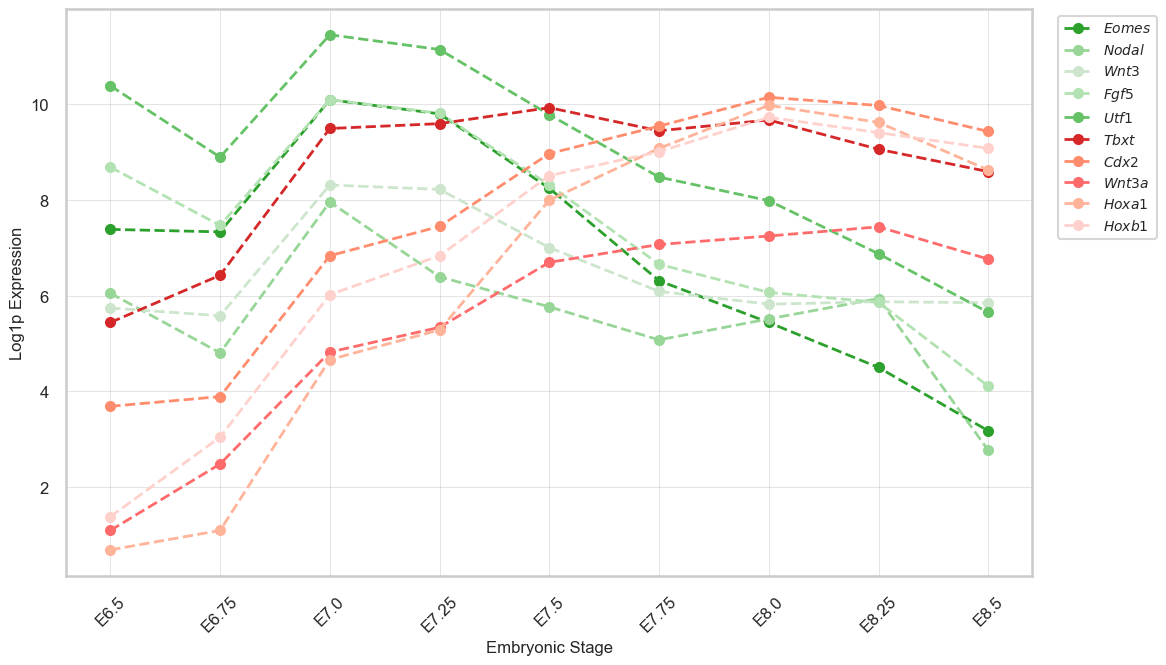

In [368]:
# contruct lineplot v2
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

palette = palette_v2
for i, gene in enumerate(genes):
    plt.plot(
        logdf.columns,
        logdf.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )

plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.xlabel('Embryonic Stage', fontsize=12)
plt.ylabel('Log1p Expression', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('../results/lineplot_embryo_pseudobulk_v2.svg', format='svg')
plt.show()

In [369]:
df = embryo_pseudo.loc[genes_black,:]

# lognormalize
logdf = np.log1p(df)

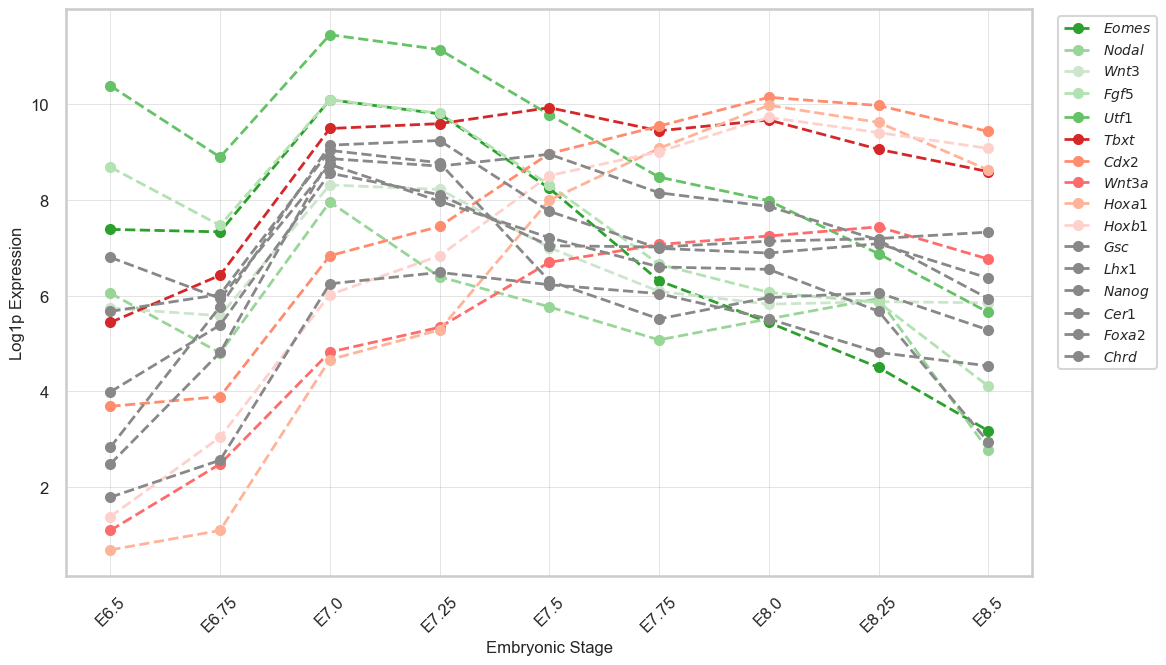

In [370]:
# contruct lineplot v2
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

palette = palette_v3
for i, gene in enumerate(genes_black):
    plt.plot(
        logdf.columns,
        logdf.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )

plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.xlabel('Embryonic Stage', fontsize=12)
plt.ylabel('Log1p Expression', fontsize=12)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.savefig('../results/lineplot_embryo_pseudobulk_v3.svg', format='svg')
plt.show()

## gastruloid lineplot

In [371]:
# gastruloid
gastruloid_bulk = pd.read_csv('../data/wnt_nodal_rnaseq/counts_chir_act_project.csv', index_col=0)
gastruloid_bulk.index = gastruloid_bulk.index.str.replace('T', 'Tbxt')

df = gastruloid_bulk.filter(regex="48h_|60h-3μM-CHIR|72h-3μM-CHIR|96h-3μM-CHIR")

In [372]:
# subset markers and lognormalze
df_ = df.loc[genes,:]
logdf = np.log1p(df_)

In [373]:
cond_names = [c.rsplit('_', 1)[0] for c in logdf.columns]

# Make a mapping from original columns to condition
col_map = dict(zip(logdf.columns, cond_names))

# Rename columns temporarily
logdf_ = logdf.rename(columns=col_map)

In [374]:
# Group by condition and calculate mean and std
mean_df = logdf_.groupby(level=0, axis=1).mean()
std_df  = logdf_.groupby(level=0, axis=1).std()


/tmp/ipykernel_10358/563452608.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_df = logdf_.groupby(level=0, axis=1).mean()
/tmp/ipykernel_10358/563452608.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df  = logdf_.groupby(level=0, axis=1).std()


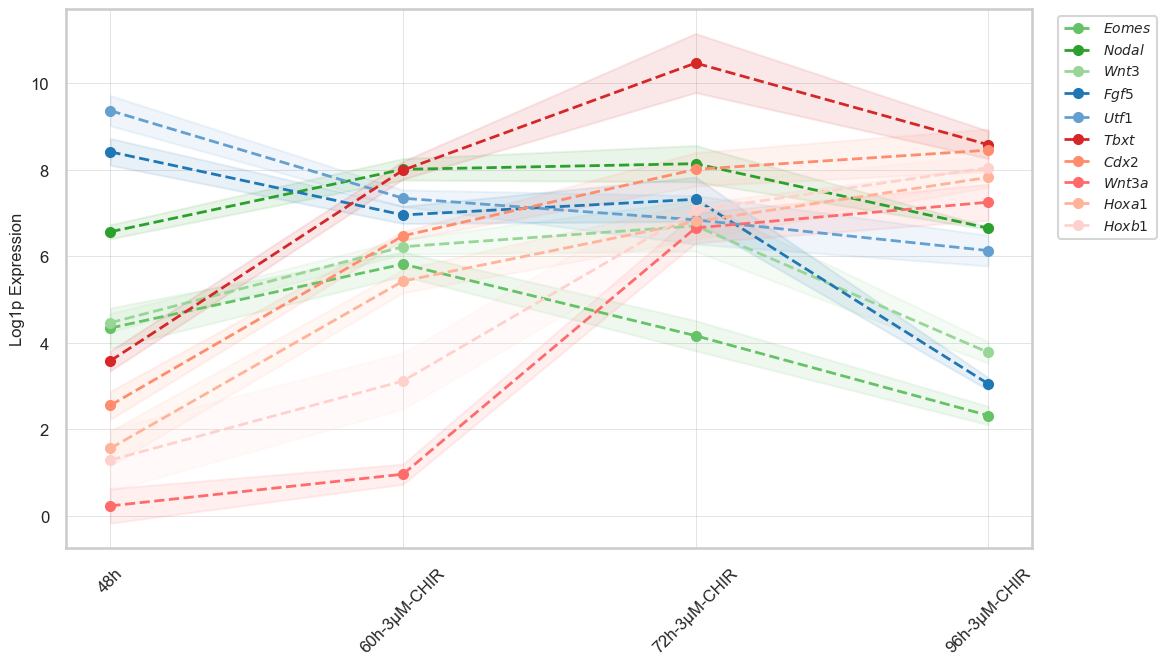

In [375]:
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))
palette = palette_v1


for i, gene in enumerate(mean_df.index):
    plt.plot(
        mean_df.columns,
        mean_df.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )
    # add shaded SD
    plt.fill_between(
        mean_df.columns,
        mean_df.loc[gene] - std_df.loc[gene],
        mean_df.loc[gene] + std_df.loc[gene],
        color=palette[gene],
        alpha=0.1
    )

plt.ylabel('Log1p Expression', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lineplot_gastruloid_v1.svg', format='svg')
plt.show()


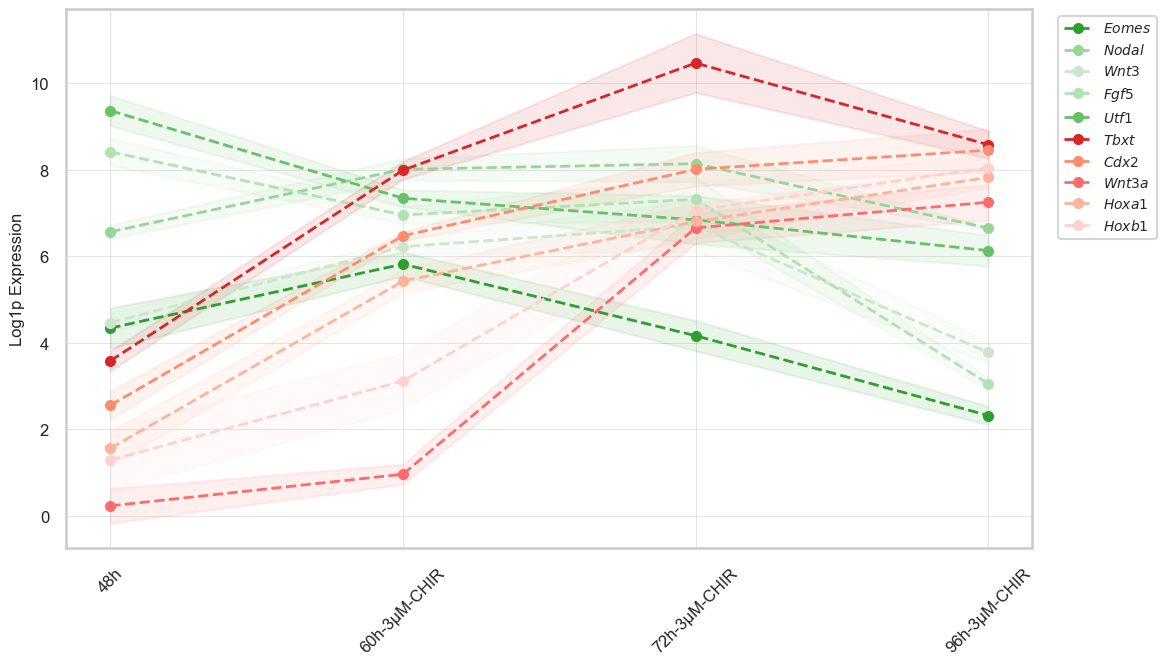

In [376]:
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))
palette = palette_v2


for i, gene in enumerate(mean_df.index):
    plt.plot(
        mean_df.columns,
        mean_df.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )
    # add shaded SD
    plt.fill_between(
        mean_df.columns,
        mean_df.loc[gene] - std_df.loc[gene],
        mean_df.loc[gene] + std_df.loc[gene],
        color=palette[gene],
        alpha=0.1
    )

plt.ylabel('Log1p Expression', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lineplot_gastruloid_v2.svg', format='svg')
plt.show()


In [377]:
# subset markers and lognormalze
df = df.loc[genes_black,:]
logdf = np.log1p(df)

In [378]:
cond_names = [c.rsplit('_', 1)[0] for c in logdf.columns]

# Make a mapping from original columns to condition
col_map = dict(zip(logdf.columns, cond_names))

# Rename columns temporarily
logdf_ = logdf.rename(columns=col_map)

# Group by condition and calculate mean and std
mean_df = logdf_.groupby(level=0, axis=1).mean()
std_df  = logdf_.groupby(level=0, axis=1).std()

/tmp/ipykernel_10358/2999868117.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  mean_df = logdf_.groupby(level=0, axis=1).mean()
/tmp/ipykernel_10358/2999868117.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  std_df  = logdf_.groupby(level=0, axis=1).std()


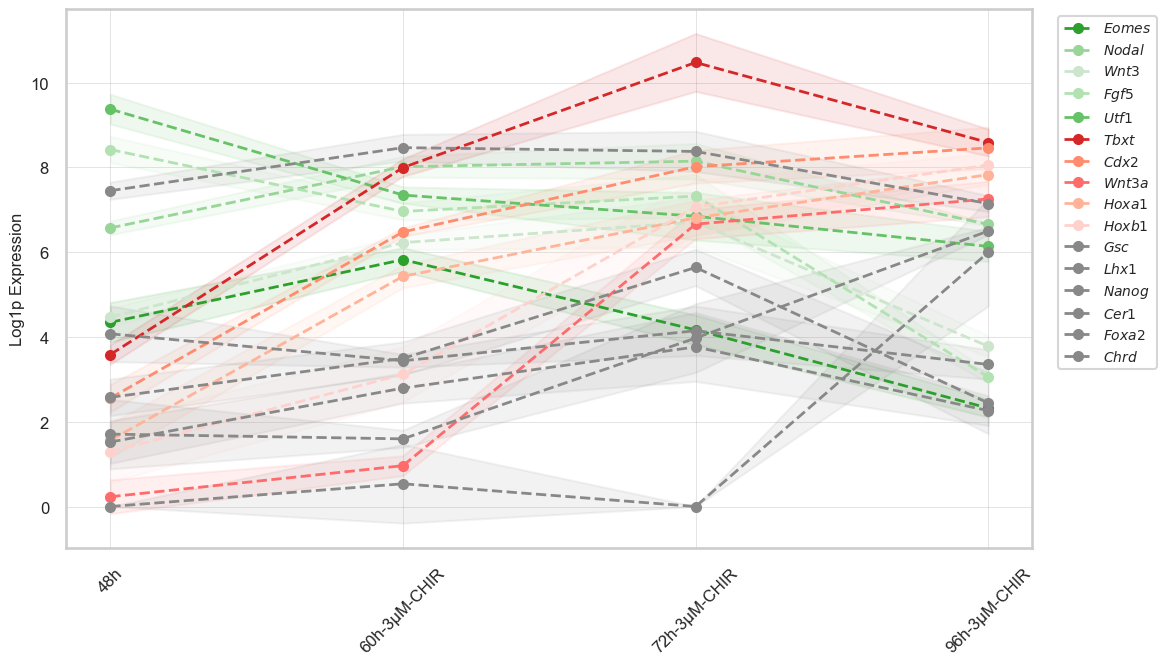

In [379]:
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))
palette = palette_v3


for i, gene in enumerate(mean_df.index):
    plt.plot(
        mean_df.columns,
        mean_df.loc[gene],
        marker='o',
        markersize=7,
        linestyle='--',
        linewidth=2,
        color=palette[gene],
        label=f"${gene}$"  # Italic in legend using LaTeX math mode
    )
    # add shaded SD
    plt.fill_between(
        mean_df.columns,
        mean_df.loc[gene] - std_df.loc[gene],
        mean_df.loc[gene] + std_df.loc[gene],
        color=palette[gene],
        alpha=0.1
    )

plt.ylabel('Log1p Expression', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linewidth=0.5, color='gray', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lineplot_gastruloid_v3.svg', format='svg')
plt.show()
